In [1]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


In [2]:
field = 'F5'
zoi_maxradpc = 100

In [3]:
# Parameters
field = "F6"


In [4]:
# --- Imports ---
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

from astropy.io import fits
from astropy.stats import SigmaClip, sigma_clipped_stats
from astropy.convolution import Gaussian2DKernel
from photutils.background import Background2D, MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from astropy.table import vstack, Table
from scipy.spatial import cKDTree
from collections import defaultdict


import os
import numpy as np
from collections import defaultdict
from scipy.spatial import cKDTree
from scipy.ndimage import map_coordinates


import json
import warnings
from time import perf_counter as clock

from scipy import ndimage
from scipy.ndimage import label as cc_label
from m33_pipeline.region_summary import write_field_region_summary, write_overall_region_summary

warnings.filterwarnings('ignore')


# --- Config (edit these) ---
        # 'NW' | 'NE' | 'SW' | 'SE'
match_radius = 20   # pixels: association radius
pad = 20            # pixels: padding around zoom cutouts for saved plots

# --- ZOI physical pixel settings ---
       # max ZoI radius [pc]
galdistance  = 0.85      # Mpc
spatial_res  = 0.32      # arcsec/pix

# --- Output dirs ---
ZOI_MAP_DIR   = f'ZOI_maps/ZOI_map_{zoi_maxradpc}pc'
REGION_STAGE_PLOT_DIR = '01_region_identification/plots'
ZOI_PLOTS_DIR = f'{REGION_STAGE_PLOT_DIR}/ZOI_plots_{zoi_maxradpc}pc/{field}'
os.makedirs(ZOI_MAP_DIR, exist_ok=True)
os.makedirs(REGION_STAGE_PLOT_DIR, exist_ok=True)
os.makedirs(ZOI_PLOTS_DIR, exist_ok=True)

# --- Folders ---
plots_dir = f'{REGION_STAGE_PLOT_DIR}/peak_plots/{field}'
SUMMARY_DIR = '01_region_identification/summary'
catalogs_dir = 'CATALOGS'   # per your spec, capitalized
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(SUMMARY_DIR, exist_ok=True)
os.makedirs(catalogs_dir, exist_ok=True)


In [5]:
# --- File paths (edit if needed) ---
continuum_fits = f"../M33-maps/M33-{field}/M33{field}-SN3Continuum.fits"
halpha_fits    = f"../M33-maps/M33-{field}/M33-{field}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits"


def read_comment_header_lines(path):
    header_lines = []
    with open(path, "r") as f:
        for line in f:
            if not line.startswith("#"):
                break
            header_lines.append(line.strip())
    return header_lines

def parse_comment_metadata(path):
    metadata = {}
    for line in read_comment_header_lines(path):
        if "=" not in line:
            continue
        key, value = line.lstrip("#").split("=", 1)
        metadata[key.strip()] = value.strip()
    return metadata

canonical_peaks_csv = f"final_peak_info/latest_peaks_{field}.csv"
if not os.path.exists(canonical_peaks_csv):
    raise FileNotFoundError(
        f"Canonical peak handoff file not found: {canonical_peaks_csv}. "
        "Run 3_finalize_peak_detection.ipynb for this field first."
    )

peaks_csv = canonical_peaks_csv
peak_metadata = parse_comment_metadata(peaks_csv)
print(f"Reading ZoI input peaks from: {peaks_csv}")
if "source_csv" in peak_metadata:
    print(f"  source peak-detection CSV: {peak_metadata['source_csv']}")
if "field" in peak_metadata and peak_metadata["field"] != str(field):
    raise ValueError(
        f"Peak CSV field mismatch: notebook field={field}, peak file field={peak_metadata['field']}"
    )

# --- Load data ---
continuum_map = fits.getdata(continuum_fits)
halpha_map    = fits.getdata(halpha_fits)

ha_peaks = pd.read_csv(peaks_csv, comment='#')
print("There are {} peaks in the ZoI input CSV file.".format(len(ha_peaks)))
if not {'x','y'}.issubset(ha_peaks.columns):
    raise ValueError("Peak list must contain 'x' and 'y' columns.")
if "field" in ha_peaks.columns:
    peak_fields = set(ha_peaks["field"].astype(str).unique())
    if peak_fields != {str(field)}:
        raise ValueError(f"Peak table contains unexpected field values: {sorted(peak_fields)}")
if ha_peaks[["x", "y"]].isna().any().any():
    raise ValueError("Peak list contains NaN x/y values.")
n_dup = int(ha_peaks.duplicated(subset=["x", "y"]).sum())
if n_dup > 0:
    print(f"[warn] Peak list contains {n_dup} duplicate x/y positions before ZoI pruning.")

ha_coords = np.vstack([ha_peaks['x'].values, ha_peaks['y'].values]).T

# Hα global LogNorm scaling helpers (for saved plots)
valid_pos = halpha_map[np.isfinite(halpha_map) & (halpha_map > 0)]
if valid_pos.size == 0:
    raise ValueError("Hα map has no positive finite values for LogNorm.")
vmin_global = np.nanpercentile(valid_pos, 5)
vmax_global = np.nanpercentile(valid_pos, 99)
if (not np.isfinite(vmin_global)) or (not np.isfinite(vmax_global)) or (vmax_global <= vmin_global):
    vmin_global, vmax_global = np.nanmin(valid_pos), np.nanmax(valid_pos)
    if not np.isfinite(vmin_global) or not np.isfinite(vmax_global) or vmax_global <= vmin_global:
        raise ValueError("Failed to compute valid global vmin/vmax for Hα.")

# Per-cutout LogNorm for saved plots
P_LO, P_HI = 3.0, 99.7
MIN_POS_PIX = 20
EPS_POS = np.nextafter(0, 1)

def local_lognorm(cutout, p_lo=P_LO, p_hi=P_HI, min_pos_pixels=MIN_POS_PIX):
    pos = cutout[np.isfinite(cutout) & (cutout > 0)]
    vmin_loc, vmax_loc = vmin_global, vmax_global
    if pos.size >= min_pos_pixels:
        lo = np.nanpercentile(pos, p_lo)
        hi = np.nanpercentile(pos, p_hi)
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            vmin_loc, vmax_loc = lo, hi
    vmin_loc = max(vmin_loc, EPS_POS)
    if not np.isfinite(vmax_loc) or vmax_loc <= vmin_loc:
        vmax_loc = vmin_loc * 1.01
    return LogNorm(vmin=vmin_loc, vmax=vmax_loc)


Reading ZoI input peaks from: final_peak_info/latest_peaks_F6.csv
  source peak-detection CSV: final_peak_info/peaks_TH_fieldF6_L15_snr6_bg25_std3_signoi3.csv
There are 263 peaks in the ZoI input CSV file.


In [6]:
# Parameters for saddle-based merging
saddle_max_dist = 20.0      # max distance [pix] between peaks to consider
saddle_threshold = 0.95      # R = I_saddle / min(I_A, I_B) above which we MERGE
profile_npts = 100         # samples along the line between peaks

# Directory for peak-removal diagnostic plots
peak_removal_dir = os.path.join(plots_dir, "peak-removal-plots")
os.makedirs(peak_removal_dir, exist_ok=True)

# Start from continuum-combined peaks
peaks_df = ha_peaks.copy()
peaks_df["removed_by_saddle"] = False
peaks_df["removed_by_edge"] = False  # will be set in later cell

coords = peaks_df[["x", "y"]].values  # (N, 2)

ny, nx = halpha_map.shape  # already defined above, but just to be sure


def sample_line_intensity(x1, y1, x2, y2, image, npts=100):
    """Sample intensities along straight line between (x1,y1) and (x2,y2)."""
    xs = np.linspace(x1, x2, npts)
    ys = np.linspace(y1, y2, npts)
    # map_coordinates expects (row, col) = (y, x)
    vals = map_coordinates(image, [ys, xs], order=1, mode="nearest")
    return vals


def peak_intensity(x, y, image):
    """Get image intensity at (x, y) with safe integer indexing."""
    ix = int(round(x))
    iy = int(round(y))
    ix = np.clip(ix, 0, image.shape[1] - 1)
    iy = np.clip(iy, 0, image.shape[0] - 1)
    return float(image[iy, ix])


# Build neighbor list using KDTree (peaks within saddle_max_dist)
tree = cKDTree(coords)
neighbors = tree.query_ball_tree(tree, r=saddle_max_dist)

# Union-find structure for merging peaks
parent = np.arange(len(peaks_df))


def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i


def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[rj] = ri

def _clip_box(xmin, xmax, ymin, ymax, nx, ny):
    xmin = int(max(0, xmin)); xmax = int(min(nx, xmax))
    ymin = int(max(0, ymin)); ymax = int(min(ny, ymax))
    return xmin, xmax, ymin, ymax

# Decide merges based on saddle ratio R = I_saddle / min(I_A, I_B)
for i in range(len(peaks_df)):
    for j in neighbors[i]:
        if j <= i:
            continue
        x1, y1 = coords[i]
        x2, y2 = coords[j]

        prof = sample_line_intensity(x1, y1, x2, y2, halpha_map, npts=profile_npts)
        I_A = peak_intensity(x1, y1, halpha_map)
        I_B = peak_intensity(x2, y2, halpha_map)
        I_saddle = np.min(prof)
        I_min_peak = min(I_A, I_B)

        if I_min_peak <= 0:
            continue

        R = I_saddle / I_min_peak

        # If saddle is shallow, treat as one region and merge
        if R > saddle_threshold:
            union(i, j)

# Group indices by connected component (merged groups)
groups = defaultdict(list)
for i in range(len(peaks_df)):
    root = find(i)
    groups[root].append(i)

# For each group with >1 peak, keep brightest and mark others as removed_by_saddle
removed_indices_saddle = []
for root, idx_list in groups.items():
    if len(idx_list) <= 1:
        continue

    # choose brightest peak in Hα
    best_idx = max(
        idx_list,
        key=lambda k: peak_intensity(
            peaks_df.loc[k, "x"], peaks_df.loc[k, "y"], halpha_map
        ),
    )

    for k in idx_list:
        if k == best_idx:
            continue
        peaks_df.loc[k, "removed_by_saddle"] = True
        removed_indices_saddle.append(k)

print(f"Saddle-based merging removed {len(removed_indices_saddle)} peaks.")

# Diagnostic plots for each peak removed by the saddle method
pad = 25  # half-size of cutout in pixels

for k in removed_indices_saddle:
    x0 = peaks_df.loc[k, "x"]
    y0 = peaks_df.loc[k, "y"]

    xmin = int(np.floor(x0 - pad))
    xmax = int(np.ceil(x0 + pad))
    ymin = int(np.floor(y0 - pad))
    ymax = int(np.ceil(y0 + pad))
    xmin, xmax, ymin, ymax = _clip_box(xmin, xmax, ymin, ymax, nx, ny)

    cut = halpha_map[ymin:ymax, xmin:xmax]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(
        cut,
        origin="lower",
        cmap="magma",
        norm=local_lognorm(cut),
        extent=(xmin, xmax, ymin, ymax),
        aspect="equal",
    )

    # all peaks in this cutout
    in_box = (peaks_df["x"].between(xmin, xmax)) & (
        peaks_df["y"].between(ymin, ymax)
    )
    ax.scatter(
        peaks_df.loc[in_box, "x"],
        peaks_df.loc[in_box, "y"],
        marker="x",
        s=30,
        color="k",
        label="Nearby peaks",
    )

    # highlight removed peak
    ax.scatter(
        [x0],
        [y0],
        marker="o",
        s=60,
        facecolor="none",
        edgecolor="cyan",
        linewidth=1.8,
        label="Removed (saddle)",
    )

    ax.set_title(f"Peak {k} removed by saddle merging")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(axis="both", which="both", labelsize=8)

    out_path = os.path.join(
        peak_removal_dir, f"{field}_peak{k}_removed_saddle.png"
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

print(f"Saddle removal diagnostic plots saved to: {peak_removal_dir}")


Saddle-based merging removed 2 peaks.


Saddle removal diagnostic plots saved to: 01_region_identification/plots/peak_plots/F6/peak-removal-plots


In [7]:
# Candidate peaks after saddle and edge filtering; the iterative ZoI prune happens later.
candidate_peaks = peaks_df.loc[
    ~peaks_df["removed_by_saddle"] & ~peaks_df["removed_by_edge"]
].copy().reset_index(drop=True)
candidate_peaks["kind"] = "peak"
print(f"Candidate peaks before iterative ZoI pruning: {len(candidate_peaks)}")

plt.figure(figsize=(20, 20))
plt.imshow(halpha_map, origin="lower", norm=local_lognorm(halpha_map))
plt.scatter(
    candidate_peaks["x"],
    candidate_peaks["y"],
    marker="o",
    s=15,
    color="r",
    label="Candidate peaks",
    alpha=0.7,
)
plt.scatter(
    peaks_df["x"],
    peaks_df["y"],
    marker="o",
    s=30,
    facecolor="none",
    edgecolor="k",
    label="Original peaks",
)
plt.title("Candidate peaks before iterative ZoI pruning")
plt.legend(fontsize=8)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.savefig(f"{plots_dir}/candidate_peaks_before_iterative_zoi_{field}.png", dpi=200)
plt.close()
print(f"Saved candidate peak plot to {plots_dir}")

Candidate peaks before iterative ZoI pruning: 261


Saved candidate peak plot to 01_region_identification/plots/peak_plots/F6


In [8]:
warnings.filterwarnings('ignore')


sizebox = 1   # 1=3x3, 2=5x5, 3=7x7, etc. (for saved plots)

# --- Region of interest (avoid edges by ~50 px unless you set explicitly) ---
# ny, nx = halpha_map.shape
# xi, xf = 50, max(50, nx-50)
# yi, yf = 50, max(50, ny-50)
xi,xf,yi,yf = np.loadtxt(f'peak_files/param_sections/param_section_{sizebox}_{field}.txt', unpack=True)
#convert to int
xi,xf,yi,yf = int(xi), int(xf), int(yi), int(yf)

# --- Choose the map that provides the "A" (amplitude) weight at peaks ---
# If you have a preprocessed amplitude map (e.g., with stars masked), point to it here:
amp3_path = f'peak_files/data_for_visualisation_OIII+Ha_{field}/M33_{field}_HaOIII_amp_nonan.fits'   # change if needed

# /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/peak_files/data_for_visualisation_OIII+Ha_NW

if os.path.exists(amp3_path):
    amp_map, header_info = fits.getdata(amp3_path, header=True)
    print(f"Using amplitude map for ZOI weights: {amp3_path}")
else:
    amp_map = halpha_map
    header_info = None
    print("Amplitude map not found; using halpha_map as weights for ZOI.")

# ZOI-0) Start from the candidate peaks and prune after an iterative ZoI pass.
new_peaks_df = candidate_peaks.copy()
print(f"Starting iterative ZoI pruning from {len(new_peaks_df)} candidate peaks")

# Sanity: ensure expected columns exist
required_cols = {"x", "y"}
missing = required_cols - set(new_peaks_df.columns)
if missing:
    raise ValueError(f"new_peaks catalog missing columns: {missing}")

use_df = new_peaks_df.copy()

def set_peak_arrays_from_df(peak_df):
    global xpic, ypic, npic
    xpic = peak_df["x"].round().astype(int).to_numpy()
    ypic = peak_df["y"].round().astype(int).to_numpy()
    npic = len(xpic)


def count_valid_halpha_pixels_by_label(zoi_labels, halpha_image, n_labels):
    counts = np.zeros(int(n_labels), dtype=int)
    finite_mask = np.isfinite(halpha_image)
    for label in range(1, int(n_labels) + 1):
        counts[label - 1] = int(np.count_nonzero((zoi_labels == label) & finite_mask))
    return counts


def label_at_peak_center(label_map, x, y):
    xi = int(round(float(x)))
    yi = int(round(float(y)))
    if yi < 0 or yi >= label_map.shape[0] or xi < 0 or xi >= label_map.shape[1]:
        return 0
    val = label_map[yi, xi]
    if np.isfinite(val) and val > 0:
        return int(round(float(val)))
    return 0


def dedupe_peaks_by_final_zoi_label(peak_df, label_map, intensity_image):
    work = peak_df.copy().reset_index(drop=True)
    work["zoi_center_label"] = [
        label_at_peak_center(label_map, x, y) for x, y in zip(work["x"], work["y"])
    ]
    if (work["zoi_center_label"] <= 0).any():
        bad = work.loc[work["zoi_center_label"] <= 0, ["x", "y", "zoi_center_label"]]
        raise RuntimeError(
            "Some retained peaks do not land on a positive ZoI label after final ZoI generation.\n"
            f"{bad.to_string(index=False)}"
        )

    duplicate_labels = work.loc[
        work["zoi_center_label"].duplicated(keep=False), "zoi_center_label"
    ].drop_duplicates().astype(int).tolist()
    if not duplicate_labels:
        return work.reset_index(drop=True), []

    removed_rows = []
    keep_indices = []
    for label in sorted(work["zoi_center_label"].astype(int).unique()):
        group = work.loc[work["zoi_center_label"] == label].copy()
        if len(group) == 1:
            keep_indices.append(group.index[0])
            continue

        group["peak_halpha_value"] = [
            peak_intensity(x, y, intensity_image) for x, y in zip(group["x"], group["y"])
        ]
        keep_idx = group["peak_halpha_value"].idxmax()
        keep_indices.append(keep_idx)
        removed_rows.append(group.loc[group.index != keep_idx].copy())

    deduped = work.loc[sorted(set(keep_indices))].copy().reset_index(drop=True)
    removed = pd.concat(removed_rows, ignore_index=True) if removed_rows else pd.DataFrame(columns=work.columns)
    return deduped, removed.to_dict(orient="records")


def iterative_prune_small_zoi_regions(
    peak_df,
    amp_image,
    halpha_image,
    roi,
    exponent,
    rmax_px,
    min_valid_pixels=20,
    max_iter=10,
):
    retained = peak_df.copy().reset_index(drop=True)
    history = []

    for iteration in range(1, max_iter + 1):
        if retained.empty:
            raise RuntimeError("Iterative ZoI pruning removed all candidate peaks.")

        set_peak_arrays_from_df(retained)
        print(
            f"Iterative ZoI pass {iteration}: computing ZoI for {len(retained)} peaks "
            f"with minimum {min_valid_pixels} valid Halpha pixels"
        )
        zoi_iter = makezoi_legacy(
            infile=amp_image,
            exponent=exponent,
            roi=roi,
            rmax_px=rmax_px,
            filep=f"ZoI_map_iter{iteration}",
        )

        counts = count_valid_halpha_pixels_by_label(zoi_iter, halpha_image, len(retained))
        retained = retained.copy()
        retained["zoi_valid_halpha_pixels"] = counts
        retained["zoi_label"] = np.arange(1, len(retained) + 1)

        history.append(retained[["zoi_label", "x", "y", "zoi_valid_halpha_pixels"]].copy())

        small_mask = retained["zoi_valid_halpha_pixels"] < int(min_valid_pixels)
        n_small = int(small_mask.sum())
        print(f"Iterative ZoI pass {iteration}: {n_small} regions below threshold")

        if n_small == 0:
            retained = retained.drop(columns=["zoi_label"])
            return retained.reset_index(drop=True), zoi_iter, history

        print("Removing small ZoI regions:")
        print(
            retained.loc[small_mask, ["zoi_label", "x", "y", "zoi_valid_halpha_pixels"]]
            .to_string(index=False)
        )
        retained = retained.loc[~small_mask].reset_index(drop=True)

    raise RuntimeError(
        f"Iterative ZoI pruning did not converge after {max_iter} iterations."
    )


def enforce_unique_final_zoi_labels(
    peak_df,
    amp_image,
    halpha_image,
    roi,
    exponent,
    rmax_px,
    min_valid_pixels=20,
    max_iter=10,
):
    retained = peak_df.copy().reset_index(drop=True)
    duplicate_history = []

    for iteration in range(1, max_iter + 1):
        set_peak_arrays_from_df(retained)
        zoi_current = makezoi_legacy(
            infile=amp_image,
            exponent=exponent,
            roi=roi,
            rmax_px=rmax_px,
            filep=f"ZoI_map_unique_iter{iteration}",
        )
        retained, removed = dedupe_peaks_by_final_zoi_label(retained, zoi_current, halpha_image)
        counts = count_valid_halpha_pixels_by_label(zoi_current, halpha_image, len(retained))
        if len(counts) == len(retained):
            retained["zoi_valid_halpha_pixels"] = counts
        duplicate_history.append(removed)
        print(f"Final-ZoI uniqueness pass {iteration}: removed {len(removed)} duplicate-center peaks")
        if len(removed) == 0:
            return retained.reset_index(drop=True), zoi_current, duplicate_history
        if len(retained) == 0:
            raise RuntimeError("Duplicate-ZoI pruning removed all peaks.")

    raise RuntimeError(
        f"Final ZoI duplicate-label pruning did not converge after {max_iter} iterations."
    )


# convert to pixels; +1 to be inclusive
zoi_maxradpi = int(zoi_maxradpc / (galdistance * 1e6 * np.tan(np.radians(spatial_res/3600)))) + 1
print(f"Galaxy distance = {galdistance} Mpc")
print(f"Spatial resolution = {spatial_res} arcsec/pix")
print(f"Max ZoI radius = {zoi_maxradpc} pc ≈ {zoi_maxradpi} pix")

# --- influence exponent (A / r^EXP) ---
INFLUENCE_EXP = 2.0

# --- clamp ROI to the array bounds in case images are small ---
xi = int(max(0, min(xi, nx-1))); xf = int(max(xi+1, min(xf, nx)))
yi = int(max(0, min(yi, ny-1))); yf = int(max(yi+1, min(yf, ny)))
print('Image portion studied xy = ', xi, xf, yi, yf)

set_peak_arrays_from_df(use_df)


Using amplitude map for ZOI weights: peak_files/data_for_visualisation_OIII+Ha_F6/M33_F6_HaOIII_amp_nonan.fits
Starting iterative ZoI pruning from 261 candidate peaks
Galaxy distance = 0.85 Mpc
Spatial resolution = 0.32 arcsec/pix
Max ZoI radius = 100 pc ≈ 76 pix
Image portion studied xy =  50 2000 50 2000


In [9]:
# Uses globals from previous cells:
# amp_map, header_info, xpic, ypic, npic, xi, xf, yi, yf, zoi_maxradpi, INFLUENCE_EXP, field
# And output dirs: ZOI_MAP_DIR

def makezoi_legacy(infile, exponent=2.0, roi=None, rmax_px=50, filep='ZoI_map'):
    """
    Reproduces the original double-loop algorithm:
    For each pixel (i,j) in ROI, among peaks within rmax_px, assign the peak that maximizes A_peak / r^exponent.
    Then remove disconnected components per peak, keeping only the component that contains the peak.
    Saves the cleaned ZOI FITS and returns the cleaned label map.
    """
    if roi is None:
        raise ValueError("ROI must be provided as (xi, xf, yi, yf)")

    xi, xf, yi, yf = roi
    h, w = infile.shape

    # 1) ZOI with all disconnected components
    print('1) Calculating ZoI (legacy, per-pixel A/r^exp)…')
    zoi_all = np.zeros_like(infile, dtype=float) / 0.0  # all NaN
    t0 = clock()

    # sample amplitude at peaks once
    A_peaks = np.nan_to_num(infile[ypic, xpic], nan=0.0, posinf=0.0, neginf=0.0)

    for i in range(xi, xf):
        # precompute dx to all peaks for this column
        distx = (xpic - i)
        for j in range(yi, yf):
            # skip invalid background pixels (match original behavior)
            if infile[j, i] == 0 or not np.isfinite(infile[j, i]):
                continue

            disty = (ypic - j)
            dist  = np.sqrt(distx*distx + disty*disty)
            k     = np.where(dist < rmax_px)[0]  # indices of nearby peaks

            if k.size == 0:
                continue

            # influence = A_peak / r^exponent (avoid r=0 issues)
            r = np.maximum(dist[k], 1e-6)
            ampdist = A_peaks[k] / np.power(r, exponent)
            if ampdist.size == 0:
                continue

            # choose winning peak index (0-based in k), store its global index (still 0-based)
            win_local = int(np.argmax(np.nan_to_num(ampdist)))
            win_peak  = int(k[win_local])
            zoi_all[j, i] = float(win_peak)  # temporary label 0..N-1

        # (optional) light progress
        if (i - xi) % 200 == 0:
            print(f'   column {i-xi}/{xf-xi}…')

    # make labels start at 1..N, leave NaNs as NaN
    valid = np.isfinite(zoi_all)
    zoi_all[valid] = zoi_all[valid] + 1.0
    print(f'   Time to calculate ZoI: {clock()-t0:.2f} s')

    # 2) Remove disconnected components (keep only the piece that contains the peak)
    print('2) Removing disconnected components (legacy)…')
    t1 = clock()
    zoi_clean = np.zeros_like(zoi_all, dtype=float)

    for ipeak in range(npic):
        L = float(ipeak + 1)  # label for this peak
        ry, rx = np.where(zoi_all == L)
        if ry.size == 0:
            continue

        # tight sub-image
        y0, y1 = max(ry.min()-1, 0), min(ry.max()+2, h)
        x0, x1 = max(rx.min()-1, 0), min(rx.max()+2, w)
        reg = np.copy(zoi_all[y0:y1, x0:x1])

        # zero out everything not this label
        reg[(reg != L)] = 0.0
        mask = (reg == L)

        lab, ncomp = cc_label(mask.astype(np.uint8))
        if ncomp <= 1:
            zoi_clean[y0:y1, x0:x1] = np.where(mask, L, zoi_clean[y0:y1, x0:x1])
        else:
            py = int(ypic[ipeak]) - y0
            px = int(xpic[ipeak]) - x0
            if py < 0 or px < 0 or py >= lab.shape[0] or px >= lab.shape[1]:
                # fallback: keep largest component
                comp_sizes = ndimage.sum(mask, lab, index=np.arange(1, ncomp+1))
                keep_comp = int(np.argmax(comp_sizes) + 1)
            else:
                keep_comp = int(lab[py, px])
            keep = (lab == keep_comp)
            zoi_clean[y0:y1, x0:x1] = np.where(keep, L, zoi_clean[y0:y1, x0:x1])

    zoi_clean[zoi_clean == 0] = np.nan
    print(f'   Time to remove disjoint components: {clock()-t1:.2f} s')

    # Save FITS
    zoi_fits_path = f"{ZOI_MAP_DIR}/{filep}_{field}.fits"
    if header_info is not None:
        fits.writeto(zoi_fits_path, zoi_clean, header_info, overwrite=True)
    else:
        fits.writeto(zoi_fits_path, zoi_clean, overwrite=True)
    print('   Saved ZOI map:', zoi_fits_path)

    return zoi_clean

def make_contours_legacy(zoi_labels, filep='ContZoI_map'):
    """
    Matches your original: XOR with a 1-pixel erosion (square footprint),
    return NaN background with 1 on edges; also saves FITS.
    """
    h, w = zoi_labels.shape
    outfile = np.zeros((h, w), dtype=float)

    for ipeak in range(npic):
        L = float(ipeak + 1)
        cy, cx = np.where(zoi_labels == L)
        if cy.size == 0:
            continue

        y0, y1 = max(cy.min()-1, 0), min(cy.max()+2, h)
        x0, x1 = max(cx.min()-1, 0), min(cx.max()+2, w)

        reg = np.copy(zoi_labels[y0:y1, x0:x1])
        reg[reg != L] = 0.0
        mask = (reg == L)

        # edge by XOR with erosion (square 3x3, like your original)
        edge = np.logical_xor(mask, ndimage.binary_erosion(mask))
        cont = np.zeros_like(reg, dtype=float)
        cont[edge] = L + 1.0  # any nonzero marker

        # accumulate 
        outfile[y0:y1, x0:x1] = np.where(cont > 0, 1.0, outfile[y0:y1, x0:x1])

    outfile[outfile == 0] = np.nan

    cont_fits_path = f"{ZOI_MAP_DIR}/{filep}_{field}.fits"
    if header_info is not None:
        fits.writeto(cont_fits_path, outfile, header_info, overwrite=True)
    else:
        fits.writeto(cont_fits_path, outfile, overwrite=True)
    print('   Saved ZOI contours:', cont_fits_path)

    return outfile


In [10]:
print(f"[CHECKPOINT] making ZoI map (~1 min)", flush=True)

roi = (xi, xf, yi, yf)
print(
    f"Running iterative ZoI pruning over ROI {roi} with r_max={zoi_maxradpi}px "
    f"and exponent={INFLUENCE_EXP}"
)

final_peaks, zoi_map_iterative, zoi_prune_history = iterative_prune_small_zoi_regions(
    peak_df=use_df,
    amp_image=amp_map,
    halpha_image=halpha_map,
    roi=roi,
    exponent=INFLUENCE_EXP,
    rmax_px=zoi_maxradpi,
    min_valid_pixels=20,
)
zoi_pruned_peaks = final_peaks.copy().reset_index(drop=True)
final_peaks = zoi_pruned_peaks.copy()
final_peaks, zoi_map, zoi_duplicate_history = enforce_unique_final_zoi_labels(
    peak_df=final_peaks,
    amp_image=amp_map,
    halpha_image=halpha_map,
    roi=roi,
    exponent=INFLUENCE_EXP,
    rmax_px=zoi_maxradpi,
    min_valid_pixels=20,
)
final_peaks = final_peaks.copy().reset_index(drop=True)
final_peaks["kind"] = "peak"
final_peaks["region_number"] = np.arange(1, len(final_peaks) + 1, dtype=int)
print(f"Final retained peaks after iterative ZoI pruning: {len(final_peaks)}")

set_peak_arrays_from_df(final_peaks)
zoi_map = makezoi_legacy(
    infile=amp_map,
    exponent=INFLUENCE_EXP,
    roi=roi,
    rmax_px=zoi_maxradpi,
    filep="ZoI_map",
)
final_peaks["zoi_center_label"] = [
    label_at_peak_center(zoi_map, x, y) for x, y in zip(final_peaks["x"], final_peaks["y"])
]
if final_peaks["zoi_center_label"].duplicated().any():
    dup = final_peaks.loc[
        final_peaks["zoi_center_label"].duplicated(keep=False),
        ["region_number", "x", "y", "zoi_center_label"],
    ].sort_values("zoi_center_label")
    raise RuntimeError(
        "Final peaks still contain duplicated ZoI center labels after uniqueness pruning.\n"
        f"{dup.to_string(index=False)}"
    )
valid_counts_final = count_valid_halpha_pixels_by_label(zoi_map, halpha_map, len(final_peaks))
if np.any(valid_counts_final < 20):
    raise RuntimeError(
        "Final ZoI map still contains regions below the 20 valid-Halpha-pixel threshold."
    )
final_peaks["zoi_valid_halpha_pixels"] = valid_counts_final
expected_labels = list(range(1, len(final_peaks) + 1))
if sorted(final_peaks["zoi_center_label"].astype(int).tolist()) != expected_labels:
    raise RuntimeError("Final peak labels are not contiguous 1..N after ZoI pruning.")
final_peak_export = final_peaks[["x", "y", "region_number", "zoi_center_label", "zoi_valid_halpha_pixels"]].copy()
final_peak_export.insert(0, "field", field)
final_peak_export["region_id"] = [f"{field}_{int(n):04d}" for n in final_peak_export["region_number"]]
final_peak_export = final_peak_export[["field", "x", "y", "region_number", "region_id", "zoi_center_label", "zoi_valid_halpha_pixels"]]
final_peak_export.to_csv(f"{catalogs_dir}/final_peaks_{field}.csv", index=False)
print(f"Saved final peaks catalog to {catalogs_dir}/final_peaks_{field}.csv")

region_summary_stats = {
    "input_peaks": int(len(ha_peaks)),
    "saddle_removed": int(peaks_df["removed_by_saddle"].sum()) if "removed_by_saddle" in peaks_df.columns else 0,
    "edge_removed": int(peaks_df["removed_by_edge"].sum()) if "removed_by_edge" in peaks_df.columns else 0,
    "candidate_peaks": int(len(candidate_peaks)),
    "zoi_small_removed": int(len(candidate_peaks) - len(zoi_pruned_peaks)),
    "zoi_duplicate_removed": int(len(zoi_pruned_peaks) - len(final_peaks)),
    "final_peaks_after_zoi": int(len(final_peaks)),
    "min_valid_pixels_threshold": 20,
    "max_zoi_pc": int(zoi_maxradpc),
}
write_field_region_summary(field, region_summary_stats, summary_dir=SUMMARY_DIR)
overall_summary_path = write_overall_region_summary(summary_dir=SUMMARY_DIR)
print(f"Updated region summary for {field}: {SUMMARY_DIR}/{field}_region_summary.txt")
print(f"Updated overall region summary: {overall_summary_path}")

plt.figure(figsize=(20, 20))
plt.imshow(halpha_map, origin="lower", norm=local_lognorm(halpha_map))
plt.scatter(
    peaks_df["x"],
    peaks_df["y"],
    marker="o",
    s=26,
    facecolor="none",
    edgecolor="k",
    label="Original peaks",
)
plt.scatter(
    final_peaks["x"],
    final_peaks["y"],
    marker="o",
    s=15,
    color="r",
    label="Final retained peaks",
    alpha=0.8,
)
plt.title("Final retained peaks after iterative ZoI pruning")
plt.legend(fontsize=8)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.savefig(f"{plots_dir}/final_retained_peaks_{field}.png", dpi=200)
plt.close()

plt.figure(figsize=(20, 20))
plt.imshow(halpha_map, origin="lower", norm=local_lognorm(halpha_map))
plt.scatter(final_peaks["x"], final_peaks["y"], marker="o", s=15, color="r", alpha=0.8)
for _, row in final_peaks.iterrows():
    plt.text(
        float(row["x"]) + 3,
        float(row["y"]) + 3,
        str(int(row["region_number"])),
        color="white",
        fontsize=6,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.15", fc="black", ec="none", alpha=0.65),
    )
plt.title("Final retained peaks with region numbers")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.savefig(f"{plots_dir}/final_retained_peaks_numbered_{field}.png", dpi=200)
plt.close()

cont_map = make_contours_legacy(zoi_map, filep="ContZoI_map")
print("Legacy ZOI complete.")


[CHECKPOINT] making ZoI map (~1 min)


Running iterative ZoI pruning over ROI (50, 2000, 50, 2000) with r_max=76px and exponent=2.0
Iterative ZoI pass 1: computing ZoI for 261 peaks with minimum 20 valid Halpha pixels
1) Calculating ZoI (legacy, per-pixel A/r^exp)…
   column 0/1950…


   column 200/1950…


   column 400/1950…


   column 600/1950…


...

   column 1800/1950…


   Time to calculate ZoI: 17.88 s
2) Removing disconnected components (legacy)…


   Time to remove disjoint components: 2.17 s
   Saved ZOI map: ZOI_maps/ZOI_map_100pc/ZoI_map_F6.fits
Saved final peaks catalog to CATALOGS/final_peaks_F6.csv


Updated region summary for F6: 01_region_identification/summary/F6_region_summary.txt
Updated overall region summary: 01_region_identification/summary/all_fields_region_summary.txt


   Saved ZOI contours: ZOI_maps/ZOI_map_100pc/ContZoI_map_F6.fits
Legacy ZOI complete.


In [11]:
unique, counts = np.unique(zoi_map[np.isfinite(zoi_map)], return_counts=True)
zoi_sizes = dict(zip(unique.astype(int), counts))

#how many have size < 10 pixels?
small_zoi = {k: v for k, v in zoi_sizes.items() if v < 100}
print(f"Number of ZOI regions with size < 10 pixels: {len(small_zoi)}")

#average zoi size
avg_zoi_size = np.mean(list(zoi_sizes.values()))
print(f"Average ZOI size (in pixels): {avg_zoi_size:.2f}")

Number of ZOI regions with size < 10 pixels: 5
Average ZOI size (in pixels): 3991.23


Saved field ZOI plot with colorbar: 01_region_identification/plots/ZOI_plots_100pc/F6/ZOI_contours_F6.png


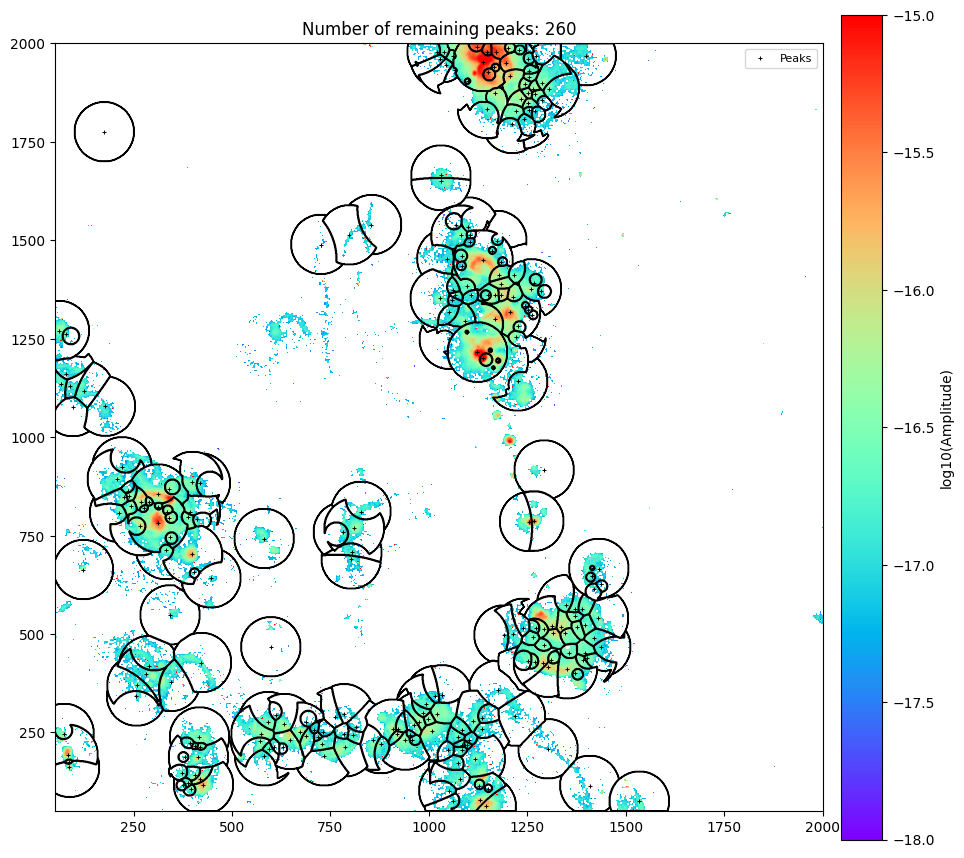

In [12]:
# ZOI-4) Save a per-field overlay plot (rainbow bg, black ZOI, labeled peaks, + colorbar)

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# choose the background (amplitude map preferred)
bg = np.copy(amp_map) if 'amp_map' in globals() else np.copy(halpha_map)

# log scale for visibility
bg_log = np.copy(bg)
bg_log[~np.isfinite(bg_log)] = np.nan
# avoid log(0)
bg_log = np.log10(np.maximum(bg_log, np.nanpercentile(bg_log[np.isfinite(bg_log)], 0.1)))

vmin = -18
vmax = -15
fig, ax = plt.subplots(figsize=(10, 10))

# show rainbow background + colorbar
im = ax.imshow(bg_log, origin='lower', cmap='rainbow', vmin=vmin, vmax=vmax, zorder=0)
cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('log10(Amplitude)', fontsize=10)

# plot peaks and text labels
ax.scatter(xpic, ypic, s=12, color='k', marker='+', lw=0.7, zorder=2, label='Peaks')
# for idx, (xp, yp) in enumerate(zip(xpic, ypic)):
#     ax.text(
#         xp + 3, yp + 3, str(idx),
#         fontsize=6, color='k', ha='left', va='bottom', zorder=3,
#         path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
#     )

# draw ZOI contours (blac k)
if np.isfinite(cont_map).any():
    edge = np.nan_to_num(cont_map, nan=0.0)
    ax.contour(edge, levels=[0.5], colors='k', linewidths=1.0, origin='lower', zorder=1)

#plot where the regions with small ZoI are
# plt.scatter(xpic[counts<100], ypic[counts<100], s=10, color='r', marker='o', facecolor='red', label='Small ZoI (<100 pix)', zorder=4)

ax.set_xlim(xi, xf)
ax.set_ylim(yi, yf)
ax.set_title(f'ZOI contours - field {field}', fontsize=12)
ax.legend(loc='upper right', fontsize=8)
plt.title("Number of remaining peaks: {}".format(len(xpic)))
out_plot = f"{ZOI_PLOTS_DIR}/ZOI_contours_{field}.png"
plt.tight_layout()
plt.savefig(out_plot, dpi=300, bbox_inches='tight')
# plt.close()

print("Saved field ZOI plot with colorbar:", out_plot)


In [13]:
xpic[counts<20]

array([], dtype=int64)